# 배터리 하이브리드 개선 모델 노트북

이 노트북은 다음 기능을 한 번에 포함합니다.

- **정규화 선택**: `robust / standard / minmax`
- **PCA 적용**
- **도메인 feature engineering**
- **정상 train 기준 불량유형 학습**
- **일반 이상탐지 + 불량유형 점수 결합**

구조는 다음과 같습니다.

1. 환경 및 설정
2. 하이브리드 모델 함수 정의
3. Charge 모델 학습
4. Discharge 모델 학습
5. 테스트 파일 평가
6. 대시보드 및 타임라인 시각화

> 기본 가정: 현재 작업 폴더 또는 `INPUT_DIR` 안에  
> `1000_chg.csv`, `1000_dchg.csv`, `Test05_NG_chg.csv`, `Test07_NG_dchg.csv` 같은 CSV가 있어야 합니다.


## 1. 실행 전 설정

아래 셀에서 `INPUT_DIR`만 실제 CSV가 있는 폴더로 맞추시면 됩니다.

- 로컬에서 현재 폴더에 CSV가 있으면 `'.'`
- 특정 폴더면 절대경로 또는 상대경로 지정

출력 파일은 `OUTPUT_DIR`에 저장됩니다.


In [1]:
import os
from pathlib import Path

INPUT_DIR = '.'
OUTPUT_DIR = './hybrid_outputs_notebook'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('INPUT_DIR =', os.path.abspath(INPUT_DIR))
print('OUTPUT_DIR =', os.path.abspath(OUTPUT_DIR))
print('CSV 개수 =', len([f for f in os.listdir(INPUT_DIR) if f.lower().endswith('.csv')]))


INPUT_DIR = /mnt/c/Users/0726b/github/Solar_Power/battery
OUTPUT_DIR = /mnt/c/Users/0726b/github/Solar_Power/battery/hybrid_outputs_notebook
CSV 개수 = 0


## 2. 하이브리드 모델 코드

아래 셀은 `.py` 파일 내용을 그대로 노트북 안에 옮긴 것입니다.  
이 셀을 한 번 실행하면 이후 학습/평가 셀을 사용할 수 있습니다.


In [21]:
from __future__ import annotations

import os
import re
import json
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
import matplotlib.pyplot as plt

CV_RE = re.compile(r"^M(\d{2})CV(\d{2})$")
T_RE = re.compile(r"^M(\d{2})T(\d{2})$")
TRAIN_FILE_RE = re.compile(r"^(?P<id>\d{4})_(?P<mode>chg|dchg)\.csv$", re.IGNORECASE)
OK_FILE_RE = re.compile(r"^Test\d+_OK_(?P<mode>chg|dchg)\.csv$", re.IGNORECASE)

DEFAULT_BAD_IDS = {
    "chg": {"1009", "1017", "1019", "1026", "1030", "1035", "1036", "1038", "1043"},
    "dchg": {"1013", "1014", "1015", "1016", "1017", "1036", "1043"},
}


@dataclass
class HybridConfig:
    input_dir: str = "."
    mode: str = "charge"  # charge | discharge
    train_files: Optional[List[str]] = None
    include_ok_as_normal: bool = True
    scaler_type: str = "robust"  # robust | standard | minmax
    pca_components: int = 12
    window: int = 100
    step: int = 5
    contamination: float = 0.01
    random_state: int = 42
    output_dir: str = "./hybrid_outputs"
    use_defect_features: bool = True  # 4개 defect score를 각각 feature로 사용
    defect_type_threshold: float = 2.5
    exclude_ids: Dict[str, set] = field(default_factory=lambda: {k: set(v) for k, v in DEFAULT_BAD_IDS.items()})


@dataclass
class HybridModel:
    config: HybridConfig
    raw_scaler: object
    eng_scaler: object
    pca: PCA
    iforest: IsolationForest
    window_threshold: float
    train_score_summary: Dict[str, float]
    defect_baseline: Dict[str, Dict[str, float]]
    raw_feature_names: List[str]
    eng_feature_names: List[str]
    defect_feature_names: List[str]
    train_files: List[str]


def _mode_to_suffix(mode: str) -> str:
    mode = mode.lower()
    if mode in ("charge", "chg"):
        return "chg"
    if mode in ("discharge", "dchg"):
        return "dchg"
    raise ValueError("mode must be one of: charge, discharge, chg, dchg")


def _sorted_sensor_cols(columns, regex):
    matched = []
    for c in columns:
        m = regex.match(c)
        if m:
            matched.append((int(m.group(1)), int(m.group(2)), c))
    return [c for _, _, c in sorted(matched)]


def _get_module_cols(columns, module_no: int, kind: str) -> List[str]:
    regex = CV_RE if kind == "CV" else T_RE
    cols = []
    for c in columns:
        m = regex.match(c)
        if m and int(m.group(1)) == module_no:
            cols.append((int(m.group(2)), c))
    return [c for _, c in sorted(cols)]


def _choose_scaler(name: str):
    name = name.lower()
    if name == "robust":
        return RobustScaler()
    if name == "standard":
        return StandardScaler()
    if name == "minmax":
        return MinMaxScaler(feature_range=(-1, 1))
    raise ValueError("scaler_type must be one of: robust, standard, minmax")


def collect_train_files(cfg: HybridConfig) -> List[str]:
    if cfg.train_files:
        return [f for f in cfg.train_files if os.path.exists(f)]

    suffix = _mode_to_suffix(cfg.mode)
    found = []
    for fn in sorted(os.listdir(cfg.input_dir)):
        p = os.path.join(cfg.input_dir, fn)
        if not os.path.isfile(p):
            continue
        m = TRAIN_FILE_RE.match(fn)
        if m and m.group("mode").lower() == suffix and m.group("id") not in cfg.exclude_ids[suffix]:
            found.append(p)
            continue
        if cfg.include_ok_as_normal:
            m2 = OK_FILE_RE.match(fn)
            if m2 and m2.group("mode").lower() == suffix:
                found.append(p)
    return found


def read_df(path: str) -> pd.DataFrame:
    return pd.read_csv(path)


def get_voltage_temp_cols(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    volt_cols = _sorted_sensor_cols(df.columns, CV_RE)
    temp_cols = _sorted_sensor_cols(df.columns, T_RE)
    return volt_cols, temp_cols


def build_row_normalized_raw(df: pd.DataFrame) -> pd.DataFrame:
    volt_cols, temp_cols = get_voltage_temp_cols(df)

    V = df[volt_cols].apply(pd.to_numeric, errors="coerce").copy()
    T = df[temp_cols].apply(pd.to_numeric, errors="coerce").copy()

    # Pack-relative normalization to preserve local imbalance patterns.
    V = V.sub(V.median(axis=1), axis=0)
    T = T.sub(T.mean(axis=1), axis=0)

    Vd = V.diff().fillna(0.0).add_suffix("_d")
    Td = T.diff().fillna(0.0).add_suffix("_d")

    X = pd.concat([V, T, Vd, Td], axis=1)

    # inf / -inf -> NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    # 1차 보간 + 앞뒤 채움 + 최종 0 대체
    X = X.interpolate(limit_direction="both")
    X = X.ffill().bfill().fillna(0.0)

    return X


def build_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    volt_cols, temp_cols = get_voltage_temp_cols(df)
    V = df[volt_cols].astype(float)
    T = df[temp_cols].astype(float)

    out = {
        "pack_v_mean": V.mean(axis=1),
        "pack_v_std": V.std(axis=1),
        "pack_v_rng": V.max(axis=1) - V.min(axis=1),
        "pack_t_mean": T.mean(axis=1),
        "pack_t_std": T.std(axis=1),
        "pack_t_rng": T.max(axis=1) - T.min(axis=1),
    }
    if "Voltage" in df.columns:
        out["pack_voltage"] = df["Voltage"].astype(float)
        out["pack_voltage_d"] = df["Voltage"].astype(float).diff().fillna(0.0)
    if "Current" in df.columns:
        out["pack_current"] = df["Current"].astype(float)
        out["pack_current_d"] = df["Current"].astype(float).diff().fillna(0.0)

    for mod in range(1, 17):
        mcols = _get_module_cols(df.columns, mod, "CV")
        if mcols:
            M = df[mcols].astype(float)
            out[f"M{mod:02d}_v_mean"] = M.mean(axis=1)
            out[f"M{mod:02d}_v_std"] = M.std(axis=1)
            out[f"M{mod:02d}_v_rng"] = M.max(axis=1) - M.min(axis=1)
            arr = M.to_numpy()
            if arr.shape[1] > 1:
                adj = np.abs(arr[:, 1:] - arr[:, :-1])
                out[f"M{mod:02d}_adj_max"] = adj.max(axis=1)
                out[f"M{mod:02d}_adj_mean"] = adj.mean(axis=1)

        tcols = _get_module_cols(df.columns, mod, "T")
        if len(tcols) >= 2:
            Tm = df[tcols].astype(float)
            out[f"M{mod:02d}_t_mean"] = Tm.mean(axis=1)
            out[f"M{mod:02d}_t_rng"] = Tm.max(axis=1) - Tm.min(axis=1)
            out[f"M{mod:02d}_t_pairdiff"] = np.abs(Tm.iloc[:, 0] - Tm.iloc[:, 1])

    F = pd.DataFrame(out).fillna(0.0)
    # Add first-order dynamics without fragmenting the DataFrame.
    diff_df = F.diff().fillna(0.0)
    diff_df.columns = [f"{c}_d" for c in F.columns]
    return pd.concat([F, diff_df], axis=1)


def aggregate_windows(X: pd.DataFrame, window: int, step: int) -> Tuple[np.ndarray, List[str], List[Tuple[int, int]]]:
    arr = np.asarray(X, dtype=float)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

    if arr.ndim != 2:
        arr = np.atleast_2d(arr)

    if len(arr) < window:
        # fallback to one padded window
        pad = np.repeat(arr[-1:, :], window - len(arr), axis=0) if len(arr) > 0 else np.zeros((window, X.shape[1]))
        arr = np.vstack([arr, pad])

    ranges = []
    rows = []
    names = list(X.columns)
    for start in range(0, len(arr) - window + 1, step):
        seg = arr[start:start + window]
        seg = np.nan_to_num(seg, nan=0.0, posinf=0.0, neginf=0.0)
        feat = np.concatenate([
            np.nan_to_num(seg.mean(axis=0), nan=0.0, posinf=0.0, neginf=0.0),
            np.nan_to_num(seg.std(axis=0), nan=0.0, posinf=0.0, neginf=0.0),
            np.nan_to_num(seg.max(axis=0), nan=0.0, posinf=0.0, neginf=0.0),
            np.nan_to_num(seg.min(axis=0), nan=0.0, posinf=0.0, neginf=0.0),
            np.nan_to_num(seg[-1] - seg[0], nan=0.0, posinf=0.0, neginf=0.0),
        ])
        feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
        rows.append(feat)
        ranges.append((start, start + window - 1))

    cols = []
    for stat in ["mean", "std", "max", "min", "delta"]:
        cols.extend([f"{c}_{stat}" for c in names])

    rows = np.asarray(rows, dtype=float)
    rows = np.nan_to_num(rows, nan=0.0, posinf=0.0, neginf=0.0)
    return rows, cols, ranges
def compute_defect_scores(df: pd.DataFrame) -> Dict[str, object]:
    volt_cols, temp_cols = get_voltage_temp_cols(df)
    V = df[volt_cols].astype(float).to_numpy()
    n = len(df)
    head = max(10, n // 5)
    tail = max(10, n // 5)

    # 1) Capacity defect: charge-tail divergence / imbalance growth.
    global_med = np.median(V, axis=1, keepdims=True)
    # Capacity imbalance is usually gradual, so clip extreme spikes that belong
    # more naturally to wire/measurement faults than to true capacity drift.
    global_dev = np.clip(np.abs(V - global_med), 0.0, 0.05)
    global_growth = float(global_dev[-tail:].mean() - global_dev[:head].mean())
    global_top1_growth = float(
        np.quantile(global_dev[-tail:].max(axis=1), 0.95)
        - np.quantile(global_dev[:head].max(axis=1), 0.95)
    )
    best_capacity_score = -np.inf
    best_capacity_cell = None
    for mod in range(1, 17):
        mcols = _get_module_cols(df.columns, mod, "CV")
        if len(mcols) < 2:
            continue
        arr = df[mcols].astype(float).to_numpy()
        med = np.median(arr, axis=1, keepdims=True)
        dev = np.clip(np.abs(arr - med), 0.0, 0.05)
        growth = dev[-tail:].mean(axis=0) - dev[:head].mean(axis=0)
        idx = int(np.argmax(growth))
        score = float(np.quantile(growth, 0.95))
        if score > best_capacity_score:
            best_capacity_score = score
            best_capacity_cell = mcols[idx]
    capacity_score = float(global_growth + global_top1_growth + best_capacity_score)

    # 2) Welding / persistent low-voltage defect.
    best_weld_score = -np.inf
    best_weld_cell = None
    for mod in range(1, 17):
        mcols = _get_module_cols(df.columns, mod, "CV")
        if len(mcols) < 2:
            continue
        arr = df[mcols].astype(float).to_numpy()
        med = np.median(arr, axis=1, keepdims=True)
        drop = np.maximum(med - arr, 0.0)
        jump = np.diff(drop, axis=0, prepend=drop[[0], :])
        cell_scores = drop.mean(axis=0) + np.quantile(drop, 0.99, axis=0) + np.quantile(jump, 0.99, axis=0)
        idx = int(np.argmax(cell_scores))
        score = float(cell_scores[idx])
        if score > best_weld_score:
            best_weld_score = score
            best_weld_cell = mcols[idx]

    # 3) Sensing wire defect: adjacent pair separation + abrupt jump.
    best_wire_score = -np.inf
    best_wire_pair = None
    for mod in range(1, 17):
        mcols = _get_module_cols(df.columns, mod, "CV")
        if len(mcols) < 2:
            continue
        arr = df[mcols].astype(float).to_numpy()
        adj = np.abs(arr[:, 1:] - arr[:, :-1])
        adj_jump = np.abs(np.diff(adj, axis=0)) if len(arr) > 1 else np.zeros_like(adj)
        pair_scores = np.quantile(adj, 0.99, axis=0) + np.quantile(adj_jump, 0.99, axis=0)
        idx = int(np.argmax(pair_scores))
        score = float(pair_scores[idx])
        if score > best_wire_score:
            best_wire_score = score
            best_wire_pair = (mcols[idx], mcols[idx + 1])

    # 4) Sensor fault: same-module temperature pair offset.
    best_sensor_score = -np.inf
    best_sensor = None
    best_sensor_peer = None
    for mod in range(1, 17):
        tcols = _get_module_cols(df.columns, mod, "T")
        if len(tcols) < 2:
            continue
        t1 = df[tcols[0]].astype(float).to_numpy()
        t2 = df[tcols[1]].astype(float).to_numpy()
        diff = np.abs(t1 - t2)
        score = float(diff.mean() + np.quantile(diff, 0.99))
        if score > best_sensor_score:
            best_sensor_score = score
            module_mean = (t1 + t2) / 2.0
            d1 = np.mean(np.abs(t1 - module_mean))
            d2 = np.mean(np.abs(t2 - module_mean))
            best_sensor = tcols[0] if d1 >= d2 else tcols[1]
            best_sensor_peer = tcols[1] if best_sensor == tcols[0] else tcols[0]

    return {
        "capacity_score": capacity_score,
        "capacity_cell": best_capacity_cell,
        "weld_score": float(best_weld_score),
        "weld_cell": best_weld_cell,
        "wire_score": float(best_wire_score),
        "wire_pair": best_wire_pair,
        "sensor_score": float(best_sensor_score),
        "sensor_sensor": best_sensor,
        "sensor_peer": best_sensor_peer,
    }


def fit_defect_baseline(train_files: List[str]) -> Dict[str, Dict[str, float]]:
    rows = []
    for f in train_files:
        rows.append(compute_defect_scores(read_df(f)))
    df = pd.DataFrame(rows)
    baseline = {}
    for col in ["capacity_score", "weld_score", "wire_score", "sensor_score"]:
        vals = df[col].astype(float).values
        med = float(np.median(vals))
        iqr = float(np.subtract(*np.percentile(vals, [75, 25])))
        scale = max(iqr, 0.1 * abs(med), 1e-6)
        baseline[col] = {
            "median": med,
            "scale": float(scale),
            "q95": float(np.quantile(vals, 0.95)),
            "max": float(np.max(vals)),
        }
    return baseline


def defect_ratios(scores: Dict[str, object], baseline: Dict[str, Dict[str, float]]) -> Dict[str, float]:
    mapping = {
        "capacity": "capacity_score",
        "weld": "weld_score",
        "wire": "wire_score",
        "sensor": "sensor_score",
    }
    ratios = {}
    for name, col in mapping.items():
        raw_score = scores.get(col, 0.0)
        try:
            raw_score = float(raw_score)
        except Exception:
            raw_score = 0.0
        if not np.isfinite(raw_score):
            raw_score = 0.0

        med = float(baseline.get(col, {}).get("median", 0.0))
        scale = float(baseline.get(col, {}).get("scale", 1.0))

        if not np.isfinite(med):
            med = 0.0
        if (not np.isfinite(scale)) or (abs(scale) < 1e-8):
            scale = 1.0

        z = (raw_score - med) / scale
        if not np.isfinite(z):
            z = 0.0
        ratios[name] = float(z)
    return ratios


DEFECT_FEATURE_NAMES = [
    "defect_capacity_z",
    "defect_weld_z",
    "defect_wire_z",
    "defect_sensor_z",
]
def build_defect_feature_frame(
    df: pd.DataFrame,
    baseline: Dict[str, Dict[str, float]],
    n_rows: Optional[int] = None,
) -> pd.DataFrame:
    defect = compute_defect_scores(df)
    ratios = defect_ratios(defect, baseline)
    if n_rows is None:
        n_rows = len(df)
    values = np.column_stack([
        np.full(n_rows, float(ratios.get("capacity", 0.0)), dtype=float),
        np.full(n_rows, float(ratios.get("weld", 0.0)), dtype=float),
        np.full(n_rows, float(ratios.get("wire", 0.0)), dtype=float),
        np.full(n_rows, float(ratios.get("sensor", 0.0)), dtype=float),
    ])
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    return pd.DataFrame(values, columns=DEFECT_FEATURE_NAMES)
def prepare_training_matrices(
    train_files: List[str],
    cfg: HybridConfig,
    defect_baseline: Optional[Dict[str, Dict[str, float]]] = None,
):
    raw_all = []
    eng_all = []
    defect_all = []
    use_defect_features = bool(cfg.use_defect_features and defect_baseline is not None)

    for f in train_files:
        df = read_df(f)
        raw_all.append(build_row_normalized_raw(df))
        eng_all.append(build_engineered_features(df))
        if use_defect_features:
            defect_all.append(build_defect_feature_frame(df, defect_baseline, n_rows=len(df)))

    raw_concat = pd.concat(raw_all, axis=0, ignore_index=True)
    eng_concat = pd.concat(eng_all, axis=0, ignore_index=True)

    raw_concat = raw_concat.replace([np.inf, -np.inf], np.nan)
    eng_concat = eng_concat.replace([np.inf, -np.inf], np.nan)

    raw_concat = raw_concat.interpolate(limit_direction="both").ffill().bfill().fillna(0.0)
    eng_concat = eng_concat.interpolate(limit_direction="both").ffill().bfill().fillna(0.0)

    raw_scaler = _choose_scaler(cfg.scaler_type)
    eng_scaler = _choose_scaler(cfg.scaler_type)

    raw_scaled = raw_scaler.fit_transform(raw_concat)
    eng_scaled = eng_scaler.fit_transform(eng_concat)

    raw_scaled = np.nan_to_num(raw_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    eng_scaled = np.nan_to_num(eng_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    pca = PCA(
        n_components=min(cfg.pca_components, raw_scaled.shape[1]),
        random_state=cfg.random_state
    )
    pca.fit(raw_scaled)

    window_rows = []
    window_cols = None
    defect_feature_names = list(DEFECT_FEATURE_NAMES) if use_defect_features else []
    for f in train_files:
        df = read_df(f)
        raw = raw_scaler.transform(build_row_normalized_raw(df))
        raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)
        pcs = pca.transform(raw)
        pcs = np.nan_to_num(pcs, nan=0.0, posinf=0.0, neginf=0.0)

        eng = eng_scaler.transform(build_engineered_features(df))
        eng = np.nan_to_num(eng, nan=0.0, posinf=0.0, neginf=0.0)

        blocks = [pcs, eng]
        cols = [f"pc{i+1}" for i in range(pcs.shape[1])] + list(eng_concat.columns)

        if use_defect_features:
            defect_df = build_defect_feature_frame(df, defect_baseline, n_rows=len(df))
            defect_arr = np.nan_to_num(defect_df.to_numpy(dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
            blocks.append(defect_arr)
            cols += defect_feature_names

        combined_arr = np.hstack(blocks)
        combined_arr = np.nan_to_num(combined_arr, nan=0.0, posinf=0.0, neginf=0.0)
        combined = pd.DataFrame(combined_arr, columns=cols)

        W, cols, _ = aggregate_windows(combined, cfg.window, cfg.step)
        W = np.nan_to_num(np.asarray(W, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)

        valid_mask = np.isfinite(W).all(axis=1)
        if not np.all(valid_mask):
            print(f"[WARN] Dropping invalid windows in {os.path.basename(f)}: {(~valid_mask).sum()} rows")
            W = W[valid_mask]

        if W.size == 0:
            print(f"[WARN] No valid windows from {os.path.basename(f)}; skipping")
            continue

        window_rows.append(W)
        window_cols = cols

    if not window_rows:
        raise ValueError("No valid training windows were created after NaN/inf filtering.")

    windows = np.vstack(window_rows)
    windows = np.nan_to_num(np.asarray(windows, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)

    valid_mask = np.isfinite(windows).all(axis=1)
    if not np.all(valid_mask):
        print(f"[WARN] Dropping invalid stacked windows: {(~valid_mask).sum()} rows")
        windows = windows[valid_mask]

    if windows.size == 0:
        raise ValueError("All training windows were removed because they contain NaN/inf.")

    return (
        raw_scaler,
        eng_scaler,
        pca,
        windows,
        window_cols,
        list(raw_concat.columns),
        list(eng_concat.columns),
        defect_feature_names,
    )
def train_hybrid_model(cfg: HybridConfig) -> HybridModel:
    os.makedirs(cfg.output_dir, exist_ok=True)
    train_files = collect_train_files(cfg)
    if not train_files:
        raise FileNotFoundError(f"No valid train files found in {cfg.input_dir} for mode={cfg.mode}")

    defect_baseline = fit_defect_baseline(train_files)

    (
        raw_scaler,
        eng_scaler,
        pca,
        windows,
        _,
        raw_feature_names,
        eng_feature_names,
        defect_feature_names,
    ) = prepare_training_matrices(train_files, cfg, defect_baseline=defect_baseline)

    windows = np.asarray(windows, dtype=float)
    windows = np.nan_to_num(windows, nan=0.0, posinf=0.0, neginf=0.0)
    valid_mask = np.isfinite(windows).all(axis=1)
    if not np.all(valid_mask):
        print(f"[WARN] Removed {(~valid_mask).sum()} invalid rows before IForest fit")
        windows = windows[valid_mask]

    if windows.size == 0 or len(windows) == 0:
        raise ValueError("No valid training rows remain after NaN/inf filtering.")

    iforest = IsolationForest(
        n_estimators=300,
        contamination=cfg.contamination,
        random_state=cfg.random_state,
    )
    iforest.fit(windows)
    train_scores = -iforest.score_samples(windows)
    train_scores = np.nan_to_num(train_scores, nan=0.0, posinf=0.0, neginf=0.0)
    window_threshold = float(np.quantile(train_scores, 0.995))

    model = HybridModel(
        config=cfg,
        raw_scaler=raw_scaler,
        eng_scaler=eng_scaler,
        pca=pca,
        iforest=iforest,
        window_threshold=window_threshold,
        train_score_summary={
            "mean": float(train_scores.mean()),
            "std": float(train_scores.std() + 1e-9),
            "q95": float(np.quantile(train_scores, 0.95)),
            "q99": float(np.quantile(train_scores, 0.99)),
        },
        defect_baseline=defect_baseline,
        raw_feature_names=raw_feature_names,
        eng_feature_names=eng_feature_names,
        defect_feature_names=defect_feature_names,
        train_files=train_files,
    )
    return model
def _combined_window_features(df: pd.DataFrame, model: HybridModel):
    raw_df = build_row_normalized_raw(df).replace([np.inf, -np.inf], np.nan)
    eng_df = build_engineered_features(df).replace([np.inf, -np.inf], np.nan)

    raw_df = raw_df.interpolate(limit_direction="both").ffill().bfill().fillna(0.0)
    eng_df = eng_df.interpolate(limit_direction="both").ffill().bfill().fillna(0.0)

    raw = model.raw_scaler.transform(raw_df)
    raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)

    pcs = model.pca.transform(raw)
    pcs = np.nan_to_num(pcs, nan=0.0, posinf=0.0, neginf=0.0)

    eng = model.eng_scaler.transform(eng_df)
    eng = np.nan_to_num(eng, nan=0.0, posinf=0.0, neginf=0.0)

    blocks = [pcs, eng]
    cols = [f"pc{i+1}" for i in range(pcs.shape[1])] + model.eng_feature_names

    if model.config.use_defect_features and model.defect_feature_names:
        defect_df = build_defect_feature_frame(df, model.defect_baseline, n_rows=len(df))
        defect_arr = np.nan_to_num(defect_df.to_numpy(dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
        blocks.append(defect_arr)
        cols += model.defect_feature_names

    combined = pd.DataFrame(np.hstack(blocks), columns=cols)
    combined = combined.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    W, agg_cols, ranges = aggregate_windows(combined, model.config.window, model.config.step)
    W = np.nan_to_num(np.asarray(W, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    valid_mask = np.isfinite(W).all(axis=1)
    if not np.all(valid_mask):
        W = W[valid_mask]
        ranges = [r for r, keep in zip(ranges, valid_mask) if keep]
    return W, agg_cols, ranges
def timestep_scores_from_windows(window_scores: np.ndarray, ranges: List[Tuple[int, int]], n_rows: int) -> np.ndarray:
    out = np.zeros(n_rows, dtype=float)
    counts = np.zeros(n_rows, dtype=float)
    for s, (a, b) in zip(window_scores, ranges):
        out[a:b + 1] += s
        counts[a:b + 1] += 1
    counts[counts == 0] = 1.0
    return out / counts


def score_file(model: HybridModel, file_path: str, label_path: Optional[str] = None) -> Dict[str, object]:
    df = read_df(file_path)
    W, _, ranges = _combined_window_features(df, model)
    window_scores = -model.iforest.score_samples(W)
    timestep_scores = timestep_scores_from_windows(window_scores, ranges, len(df))

    defect = compute_defect_scores(df)
    ratios = defect_ratios(defect, model.defect_baseline)
    weighted = ratios.copy()
    if _mode_to_suffix(model.config.mode) == "chg":
        weighted["capacity"] *= 1.2
    else:
        weighted["wire"] *= 1.1
    pred_type = max(weighted, key=weighted.get)
    type_score = max(0.0, max(weighted.values()))

    # Hybrid anomaly score: generic window anomaly + defect-type anomaly.
    window_q99 = float(np.quantile(window_scores, 0.99))
    generic_score = (window_q99 - model.train_score_summary["q95"]) / max(model.train_score_summary["std"], 1e-6)
    hybrid_score = max(type_score, generic_score)
    is_anomaly = bool((window_q99 > model.window_threshold) or (type_score > 2.5))

    metrics = None
    if label_path and os.path.exists(label_path):
        lab = pd.read_csv(label_path)
        y_true = lab.iloc[:, -1].astype(int).to_numpy()
        y_pred = (timestep_scores >= np.quantile(timestep_scores, 0.98)).astype(int)
        n = min(len(y_true), len(y_pred))
        y_true = y_true[:n]
        y_pred = y_pred[:n]
        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        acc = (tp + tn) / max(len(y_true), 1)
        metrics = {
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
        }

    return {
        "file": file_path,
        "df": df,
        "window_scores": window_scores,
        "window_ranges": ranges,
        "timestep_scores": timestep_scores,
        "window_q99": window_q99,
        "generic_score": float(generic_score),
        "type_score": float(type_score),
        "hybrid_score": float(hybrid_score),
        "is_anomaly": is_anomaly,
        "pred_type": pred_type,
        "type_ratios": ratios,
        "defect": defect,
        "metrics": metrics,
    }


def plot_defect_dashboard(result: Dict[str, object], title: Optional[str] = None):
    df = result["df"]
    defect = result["defect"]
    ratios = result["type_ratios"]
    volt_cols, temp_cols = get_voltage_temp_cols(df)

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)

    # 1) Capacity defect
    for c in volt_cols:
        axes[0, 0].plot(df.index, df[c], color="lightgray", alpha=0.25)
    if defect["capacity_cell"] is not None:
        axes[0, 0].plot(
            df.index,
            df[defect["capacity_cell"]],
            color="red",
            linewidth=2.2,
            label=f"{defect['capacity_cell']} | score={ratios['capacity']:.2f}",
        )
    axes[0, 0].set_title(
        "1. Capacity defect (end-of-discharge deviation growth)",
        fontsize=14,
        fontweight="bold",
    )
    axes[0, 0].legend(loc="best")

    # 2) Weld / low voltage defect
    for c in volt_cols:
        axes[0, 1].plot(df.index, df[c], color="lightgray", alpha=0.25)
    if defect["weld_cell"] is not None:
        axes[0, 1].plot(
            df.index,
            df[defect["weld_cell"]],
            color="blue",
            linewidth=2.2,
            label=f"{defect['weld_cell']} | score={ratios['weld']:.2f}",
        )
    axes[0, 1].set_title(
        "2. Weld / low-voltage defect",
        fontsize=14,
        fontweight="bold",
    )
    axes[0, 1].legend(loc="best")

    # 3) Sensing wire defect
    for c in volt_cols:
        axes[1, 0].plot(df.index, df[c], color="lightgray", alpha=0.20)
    if defect["wire_pair"] is not None:
        a, b = defect["wire_pair"]
        axes[1, 0].plot(df.index, df[a], color="purple", linewidth=2.0, label=a)
        axes[1, 0].plot(
            df.index,
            df[b],
            color="green",
            linewidth=2.0,
            label=f"{b} | score={ratios['wire']:.2f}",
        )
    axes[1, 0].set_title(
        "3. Sensing wire defect (adjacent cell pair)",
        fontsize=14,
        fontweight="bold",
    )
    axes[1, 0].legend(loc="best")

    # 4) Temperature sensor defect
    for c in temp_cols:
        axes[1, 1].plot(df.index, df[c], color="lightgray", alpha=0.25)
    if defect["sensor_sensor"] is not None:
        s1 = defect["sensor_sensor"]
        s2 = defect["sensor_peer"]
        axes[1, 1].plot(
            df.index,
            df[s1],
            color="orange",
            linewidth=2.5,
            label=f"{s1} | score={ratios['sensor']:.2f}",
        )
        axes[1, 1].plot(
            df.index,
            df[s2],
            color="black",
            linewidth=1.4,
            linestyle="--",
            label=f"peer={s2}",
        )
    axes[1, 1].set_title(
        "4. Temperature sensor defect (module pair comparison)",
        fontsize=14,
        fontweight="bold",
    )
    axes[1, 1].legend(loc="best")

    t = title or os.path.basename(result["file"])
    plt.suptitle(
        f"{t}\nPredicted defect type: {result['pred_type']} | hybrid_score={result['hybrid_score']:.2f} | anomaly={result['is_anomaly']}",
        fontsize=20,
        fontweight="bold",
    )

    plt.show()


def plot_anomaly_timeline(result: Dict[str, object], threshold_quantile: float = 0.98):
    scores = np.asarray(result["timestep_scores"], dtype=float)
    df = result["df"]
    thr = float(np.quantile(scores, threshold_quantile))
    plt.figure(figsize=(16, 4))
    plt.plot(df.index, scores, label="timestep anomaly score")
    plt.axhline(thr, color="red", linestyle="--", label=f"q{int(threshold_quantile*100)}")
    plt.title(f"Anomaly timeline: {os.path.basename(result['file'])}")
    plt.xlabel("time index")
    plt.ylabel("score")
    plt.legend()
    plt.tight_layout()
    plt.show()


def save_model(model: HybridModel, path: str):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    joblib.dump(model, path)


def load_model(path: str) -> HybridModel:
    return joblib.load(path)


def demo_train_and_score(input_dir: str, output_dir: str = "./hybrid_outputs"):
    # Charge model
    chg_cfg = HybridConfig(input_dir=input_dir, output_dir=output_dir, mode="charge", include_ok_as_normal=True)
    dchg_cfg = HybridConfig(input_dir=input_dir, output_dir=output_dir, mode="discharge", include_ok_as_normal=True)
    chg_model = train_hybrid_model(chg_cfg)
    dchg_model = train_hybrid_model(dchg_cfg)

    tests = [
        ("charge", os.path.join(input_dir, "Test05_NG_chg.csv"), None),
        ("charge", os.path.join(input_dir, "Test06_NG_chg.csv"), None),
        ("discharge", os.path.join(input_dir, "Test07_NG_dchg.csv"), None),
        ("charge", os.path.join(input_dir, "Test08_NG_chg.csv"), os.path.join(input_dir, "Test08_NG_chg_Label.csv")),
        ("discharge", os.path.join(input_dir, "Test09_NG_dchg.csv"), os.path.join(input_dir, "Test09_NG_dchg_Label.csv")),
    ]
    rows = []
    for mode, csv_path, label_path in tests:
        model = chg_model if mode == "charge" else dchg_model
        if os.path.exists(csv_path):
            res = score_file(model, csv_path, label_path)
            rows.append({
                "file": os.path.basename(csv_path),
                "pred_type": res["pred_type"],
                "hybrid_score": res["hybrid_score"],
                "is_anomaly": res["is_anomaly"],
                **{f"ratio_{k}": v for k, v in res["type_ratios"].items()},
            })
    summary = pd.DataFrame(rows)
    os.makedirs(output_dir, exist_ok=True)
    summary.to_csv(os.path.join(output_dir, "demo_summary.csv"), index=False)
    return summary

## 3-1. 이번 최종 수정 핵심

- 기존: 4개 불량 score에서 `max` 중심으로 최종 판단
- 수정: `capacity / weld / wire / sensor` 4개 score를 **각각 별도 feature**로 IForest 입력에 추가
- 유지: 최종 표시용 `pred_type`, `type_score_max`, `type_score_sum`도 함께 저장

즉, 이제는 **합산만 하는 방식이 아니라 4개 불량 점수를 분리해서 학습**합니다.


## 3. 학습 후보 파일 확인

- `charge`는 정상 `*_chg.csv` + 선택적으로 `Test*_OK_chg.csv`
- `discharge`는 정상 `*_dchg.csv` + 선택적으로 `Test*_OK_dchg.csv`

사용자가 앞서 정리한 **비정상 train ID**는 기본 제외됩니다.


In [22]:
# Charge 후보
chg_cfg_preview = HybridConfig(input_dir=INPUT_DIR, output_dir=OUTPUT_DIR, mode='charge', include_ok_as_normal=True)
dchg_cfg_preview = HybridConfig(input_dir=INPUT_DIR, output_dir=OUTPUT_DIR, mode='discharge', include_ok_as_normal=True)

chg_files = collect_train_files(chg_cfg_preview)
dchg_files = collect_train_files(dchg_cfg_preview)

print('[Charge 학습 후보]')
for f in chg_files:
    print(' -', os.path.basename(f))

print('\n[Discharge 학습 후보]')
for f in dchg_files:
    print(' -', os.path.basename(f))


[Charge 학습 후보]
 - 1000_chg.csv
 - 1001_chg.csv
 - 1002_chg.csv
 - 1003_chg.csv
 - 1004_chg.csv
 - 1005_chg.csv
 - 1006_chg.csv
 - 1007_chg.csv
 - 1008_chg.csv
 - 1010_chg.csv
 - 1011_chg.csv
 - 1012_chg.csv
 - 1013_chg.csv
 - 1014_chg.csv
 - 1015_chg.csv
 - 1016_chg.csv
 - 1018_chg.csv
 - 1020_chg.csv
 - 1021_chg.csv
 - 1022_chg.csv
 - 1023_chg.csv
 - 1024_chg.csv
 - 1025_chg.csv
 - 1027_chg.csv
 - 1028_chg.csv
 - 1029_chg.csv
 - 1031_chg.csv
 - 1032_chg.csv
 - 1033_chg.csv
 - 1034_chg.csv
 - 1037_chg.csv
 - 1039_chg.csv
 - 1040_chg.csv
 - 1041_chg.csv
 - 1042_chg.csv
 - 1044_chg.csv
 - 1045_chg.csv
 - 1046_chg.csv
 - 1047_chg.csv
 - 1048_chg.csv
 - 1049_chg.csv
 - 1050_chg.csv

[Discharge 학습 후보]
 - 1000_dchg.csv
 - 1001_dchg.csv
 - 1002_dchg.csv
 - 1003_dchg.csv
 - 1004_dchg.csv
 - 1005_dchg.csv
 - 1006_dchg.csv
 - 1007_dchg.csv
 - 1008_dchg.csv
 - 1009_dchg.csv
 - 1010_dchg.csv
 - 1011_dchg.csv
 - 1012_dchg.csv
 - 1018_dchg.csv
 - 1019_dchg.csv
 - 1020_dchg.csv
 - 1021_dchg.csv
 - 10

## 4. Charge 모델 학습

`Test05`, `Test06`, `Test08`처럼 **충전 계열 평가**에 사용합니다.

기본 권장값:
- `scaler_type='robust'`
- `pca_components=12`
- `window=30`
- `step=5`


In [23]:
import os, re

folder = r'/mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/train'
bad_chg = {'1009', '1017', '1019', '1026', '1030', '1035', '1036', '1038', '1043'}

pat = re.compile(r'^(\d{4})_(chg|dchg)\.csv$', re.IGNORECASE)

valid_charge = []
for f in os.listdir(folder):
    m = pat.match(f)
    if not m:
        continue
    fid, mode = m.group(1), m.group(2).lower()
    if mode == 'chg' and fid not in bad_chg:
        valid_charge.append(f)

print(sorted(valid_charge))
print("valid charge count =", len(valid_charge))

['1000_chg.csv', '1001_chg.csv', '1002_chg.csv', '1003_chg.csv', '1004_chg.csv', '1005_chg.csv', '1006_chg.csv', '1007_chg.csv', '1008_chg.csv', '1010_chg.csv', '1011_chg.csv', '1012_chg.csv', '1013_chg.csv', '1014_chg.csv', '1015_chg.csv', '1016_chg.csv', '1018_chg.csv', '1020_chg.csv', '1021_chg.csv', '1022_chg.csv', '1023_chg.csv', '1024_chg.csv', '1025_chg.csv', '1027_chg.csv', '1028_chg.csv', '1029_chg.csv', '1031_chg.csv', '1032_chg.csv', '1033_chg.csv', '1034_chg.csv', '1037_chg.csv', '1039_chg.csv', '1040_chg.csv', '1041_chg.csv', '1042_chg.csv', '1044_chg.csv', '1045_chg.csv', '1046_chg.csv', '1047_chg.csv', '1048_chg.csv', '1049_chg.csv', '1050_chg.csv']
valid charge count = 42


In [24]:
INPUT_DIR = r'/mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/train'
OUTPUT_DIR = './hybrid_outputs'

In [25]:
chg_cfg = HybridConfig(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    mode='charge',
    include_ok_as_normal=True,
    scaler_type='robust',
    pca_components=12,
    window=100,
    step=5,
)

chg_model = train_hybrid_model(chg_cfg)
chg_model.train_score_summary


{'mean': 0.42843608944289446,
 'std': 0.03103711500269412,
 'q95': 0.49208892957376343,
 'q99': 0.5486633302938343}

## 5. Discharge 모델 학습

`Test07`, `Test09`처럼 **방전 계열 평가**에 사용합니다.


In [26]:
dchg_cfg = HybridConfig(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    mode='discharge',
    include_ok_as_normal=True,
    scaler_type='robust',
    pca_components=12,
    window=100,
    step=5,
)

dchg_model = train_hybrid_model(dchg_cfg)
dchg_model.train_score_summary


{'mean': 0.42619012561985836,
 'std': 0.03586080279571328,
 'q95': 0.506848201336289,
 'q99': 0.5419425272932888}

## 6. 모델 저장

원하시면 학습한 모델을 파일로 저장할 수 있습니다.


In [27]:
chg_model_path = os.path.join(OUTPUT_DIR, 'hybrid_charge_model.joblib')
dchg_model_path = os.path.join(OUTPUT_DIR, 'hybrid_discharge_model.joblib')

save_model(chg_model, chg_model_path)
save_model(dchg_model, dchg_model_path)

print(chg_model_path)
print(dchg_model_path)


./hybrid_outputs/hybrid_charge_model.joblib
./hybrid_outputs/hybrid_discharge_model.joblib


## 7. 테스트 파일 평가

아래 셀은 Test05~09를 한 번에 평가합니다.

- Charge 파일은 `chg_model`
- Discharge 파일은 `dchg_model`

결과는 표 형태로 정리됩니다.


In [28]:
test_specs = [
    ('charge', 'Test01_OK_chg.csv', 'Test01_OK_chg_Label.csv'),
    ('discharge', 'Test02_OK_dchg.csv', 'Test02_OK_dchg_Label.csv'),
    ('charge', 'Test03_OK_chg.csv', 'Test03_OK_chg_Label.csv'),
    ('discharge', 'Test04_OK_dchg.csv', 'Test04_OK_dchg_Label.csv'),
    ('charge', 'Test05_NG_chg.csv', None),
    ('charge', 'Test06_NG_chg.csv', 'Test06_NG_chg_Label.csv'),
    ('discharge', 'Test07_NG_dchg.csv', 'Test07_NG_dchg_Label.csv'),
    ('charge', 'Test08_NG_chg.csv', 'Test08_NG_chg_Label.csv'),
    ('discharge', 'Test09_NG_dchg.csv', 'Test09_NG_dchg_Label.csv'),
]

TRAIN_DIR = "/mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/train"
TEST_RAW_DIR = "/mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/test"
TEST_LABEL_DIR = "/mnt/c/Users/0726b/github/Solar_Power/battery/data/preprocessed/test"

rows = []
results = {}

for mode, csv_name, label_name in test_specs:
    print(f"\n--- processing: {csv_name} ({mode}) ---")

    csv_path = os.path.join(TEST_RAW_DIR, csv_name)
    label_path = os.path.join(TEST_LABEL_DIR, label_name) if label_name else None

    print("csv_path =", csv_path)
    print("label_path =", label_path)
    print("csv exists =", os.path.exists(csv_path))
    print("label exists =", os.path.exists(label_path) if label_path else None)

    if not os.path.exists(csv_path):
        print('파일 없음:', csv_path)
        continue

    model = chg_model if mode == 'charge' else dchg_model
    res = score_file(model, csv_path, label_path)
    results[csv_name] = res

    row = {
        'file': csv_name,
        'mode': mode,
        'pred_type': res['pred_type'],
        'hybrid_score': res['hybrid_score'],
        'is_anomaly': res['is_anomaly'],
        'ratio_capacity': res['type_ratios'].get('capacity'),
        'ratio_weld': res['type_ratios'].get('weld'),
        'ratio_wire': res['type_ratios'].get('wire'),
        'ratio_sensor': res['type_ratios'].get('sensor'),
    }

    if res.get('metrics'):
        for k, v in res['metrics'].items():
            row[k] = v

    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df



--- processing: Test01_OK_chg.csv (charge) ---
csv_path = /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/test/Test01_OK_chg.csv
label_path = /mnt/c/Users/0726b/github/Solar_Power/battery/data/preprocessed/test/Test01_OK_chg_Label.csv
csv exists = True
label exists = True

--- processing: Test02_OK_dchg.csv (discharge) ---
csv_path = /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/test/Test02_OK_dchg.csv
label_path = /mnt/c/Users/0726b/github/Solar_Power/battery/data/preprocessed/test/Test02_OK_dchg_Label.csv
csv exists = True
label exists = True

--- processing: Test03_OK_chg.csv (charge) ---
csv_path = /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/test/Test03_OK_chg.csv
label_path = /mnt/c/Users/0726b/github/Solar_Power/battery/data/preprocessed/test/Test03_OK_chg_Label.csv
csv exists = True
label exists = True

--- processing: Test04_OK_dchg.csv (discharge) ---
csv_path = /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/test/Test04_O

,file,mode,pred_type,hybrid_score,is_anomaly,ratio_capacity,ratio_weld,ratio_wire,ratio_sensor,accuracy,precision,recall,f1
0,Test01_OK_chg.csv,charge,capacity,5.410083,True,NaN,1.207024,1.739130e+00,0.759975,0.979687,0.000000,0.000000,0.000000
1,Test02_OK_dchg.csv,discharge,capacity,2.332237,True,NaN,2.785794,1.019368e+00,0.001412,0.975466,0.000000,0.000000,0.000000
2,Test03_OK_chg.csv,charge,capacity,4.153200,True,NaN,-0.039750,1.158494e-13,-0.427374,0.978888,0.000000,0.000000,0.000000
3,Test04_OK_dchg.csv,discharge,capacity,2.993570,True,NaN,0.108179,-2.038736e-01,-0.566474,0.976744,0.000000,0.000000,0.000000
4,Test05_NG_chg.csv,charge,capacity,2.603080,True,NaN,0.006822,6.956522e-01,-0.376747,NaN,NaN,NaN,NaN
5,Test06_NG_chg.csv,charge,capacity,3.619216,True,NaN,-1.234809,4.711144e+03,-1.187706,0.023419,1.000000,0.023419,0.045767
6,Test07_NG_dchg.csv,discharge,capacity,0.486827,False,NaN,174.244614,2.290709e+02,-0.610261,0.968219,0.926316,0.387665,0.546584
7,Test08_NG_chg.csv,charge,capacity,4.311744,True,NaN,0.779163,5.565217e-01,7.887483,0.020868,1.000000,0.020868,0.040883
8,Test09_NG_dchg.csv,discharge,capacity,1.380652,True,NaN,1.061526,4.152905e-01,3.394243,0.020559,1.000000,0.020559,0.040290


## 8. 결과 저장

요약 결과를 CSV로 저장합니다.


In [29]:
summary_path = os.path.join(OUTPUT_DIR, 'hybrid_test_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(summary_path)


./hybrid_outputs/hybrid_test_summary.csv


In [30]:
import os

print("INPUT_DIR =", INPUT_DIR)
print("parent =", os.path.dirname(INPUT_DIR))

parent = os.path.dirname(INPUT_DIR)
for folder in sorted(os.listdir(parent)):
    path = os.path.join(parent, folder)
    print(folder, "->", path)

INPUT_DIR = /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/train
parent = /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data
test -> /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/test
train -> /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/train


In [31]:
TEST_DIR = os.path.join(os.path.dirname(INPUT_DIR), "test")
print("TEST_DIR =", TEST_DIR)
print("exists =", os.path.exists(TEST_DIR))

for f in sorted(os.listdir(TEST_DIR)):
    print(f)

TEST_DIR = /mnt/c/Users/0726b/github/Solar_Power/battery/data/raw_data/test
exists = True
Test01_OK_chg.csv
Test02_OK_dchg.csv
Test03_OK_chg.csv
Test04_OK_dchg.csv
Test05_NG_chg.csv
Test06_NG_chg.csv
Test07_NG_dchg.csv
Test08_NG_chg.csv
Test09_NG_dchg.csv


## 9. 개별 파일 시각화

아래에서 보고 싶은 파일명을 바꾸면 됩니다.

예:
- `'Test05_NG_chg.csv'`
- `'Test07_NG_dchg.csv'`
- `'Test08_NG_chg.csv'`
- `'Test09_NG_dchg.csv'`


In [32]:
print(results.keys())

dict_keys(['Test01_OK_chg.csv', 'Test02_OK_dchg.csv', 'Test03_OK_chg.csv', 'Test04_OK_dchg.csv', 'Test05_NG_chg.csv', 'Test06_NG_chg.csv', 'Test07_NG_dchg.csv', 'Test08_NG_chg.csv', 'Test09_NG_dchg.csv'])


In [33]:
TARGET_FILE = 'Test09_NG_dchg.csv'
res = results[TARGET_FILE]

print(f"Predicted defect type: {res['pred_type']}")
print(f"Hybrid score: {res['hybrid_score']}")
print(f"Type ratios: {res['type_ratios']}")
if res.get('metrics'):
    print(f"Evaluation metrics: {res['metrics']}")


Predicted defect type: capacity
Hybrid score: 1.3806524207187243
Type ratios: {'capacity': nan, 'weld': 1.061525789824931, 'wire': 0.4152905198777922, 'sensor': 3.394242691429458}
Evaluation metrics: {'accuracy': 0.02055921052631579, 'precision': 0.99999999999, 'recall': 0.02055921052631156, 'f1': 0.04029008859870033}


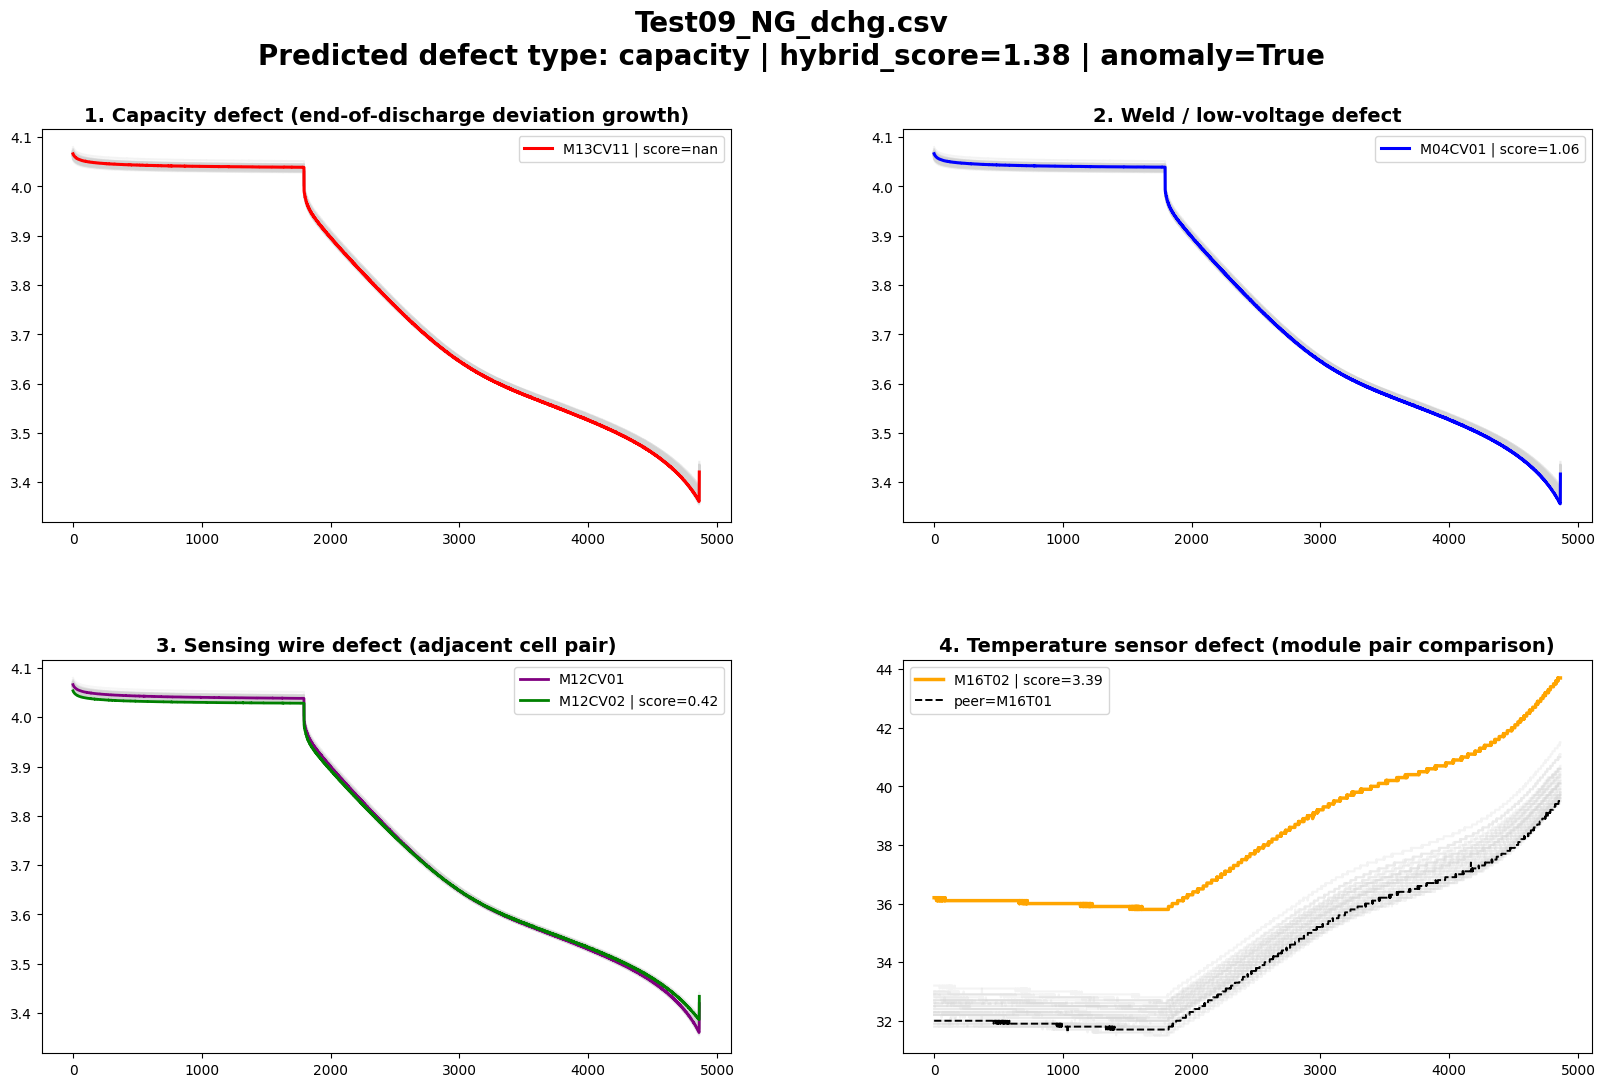

In [34]:
plot_defect_dashboard(res)


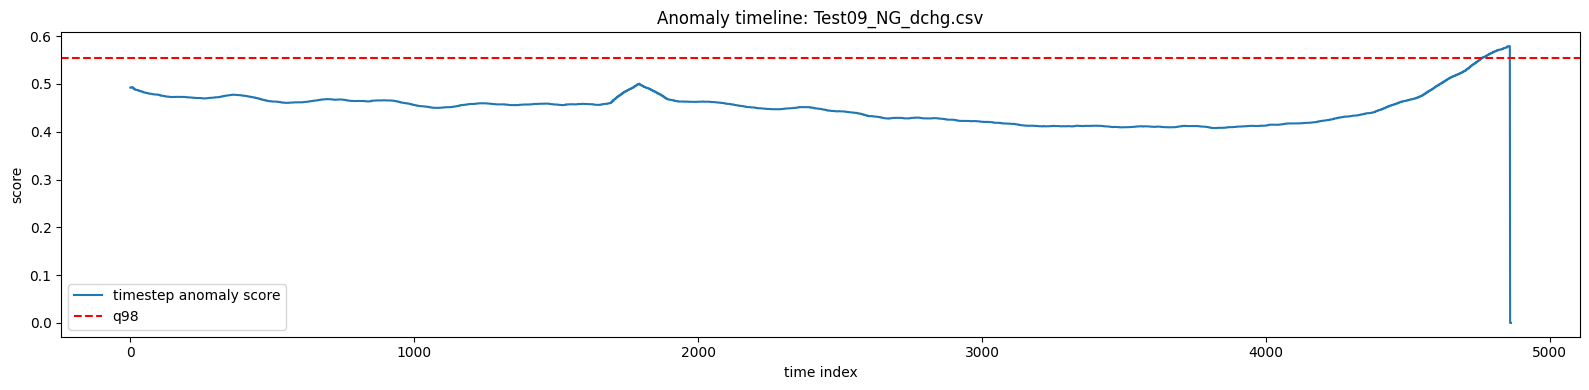

In [35]:
plot_anomaly_timeline(res)


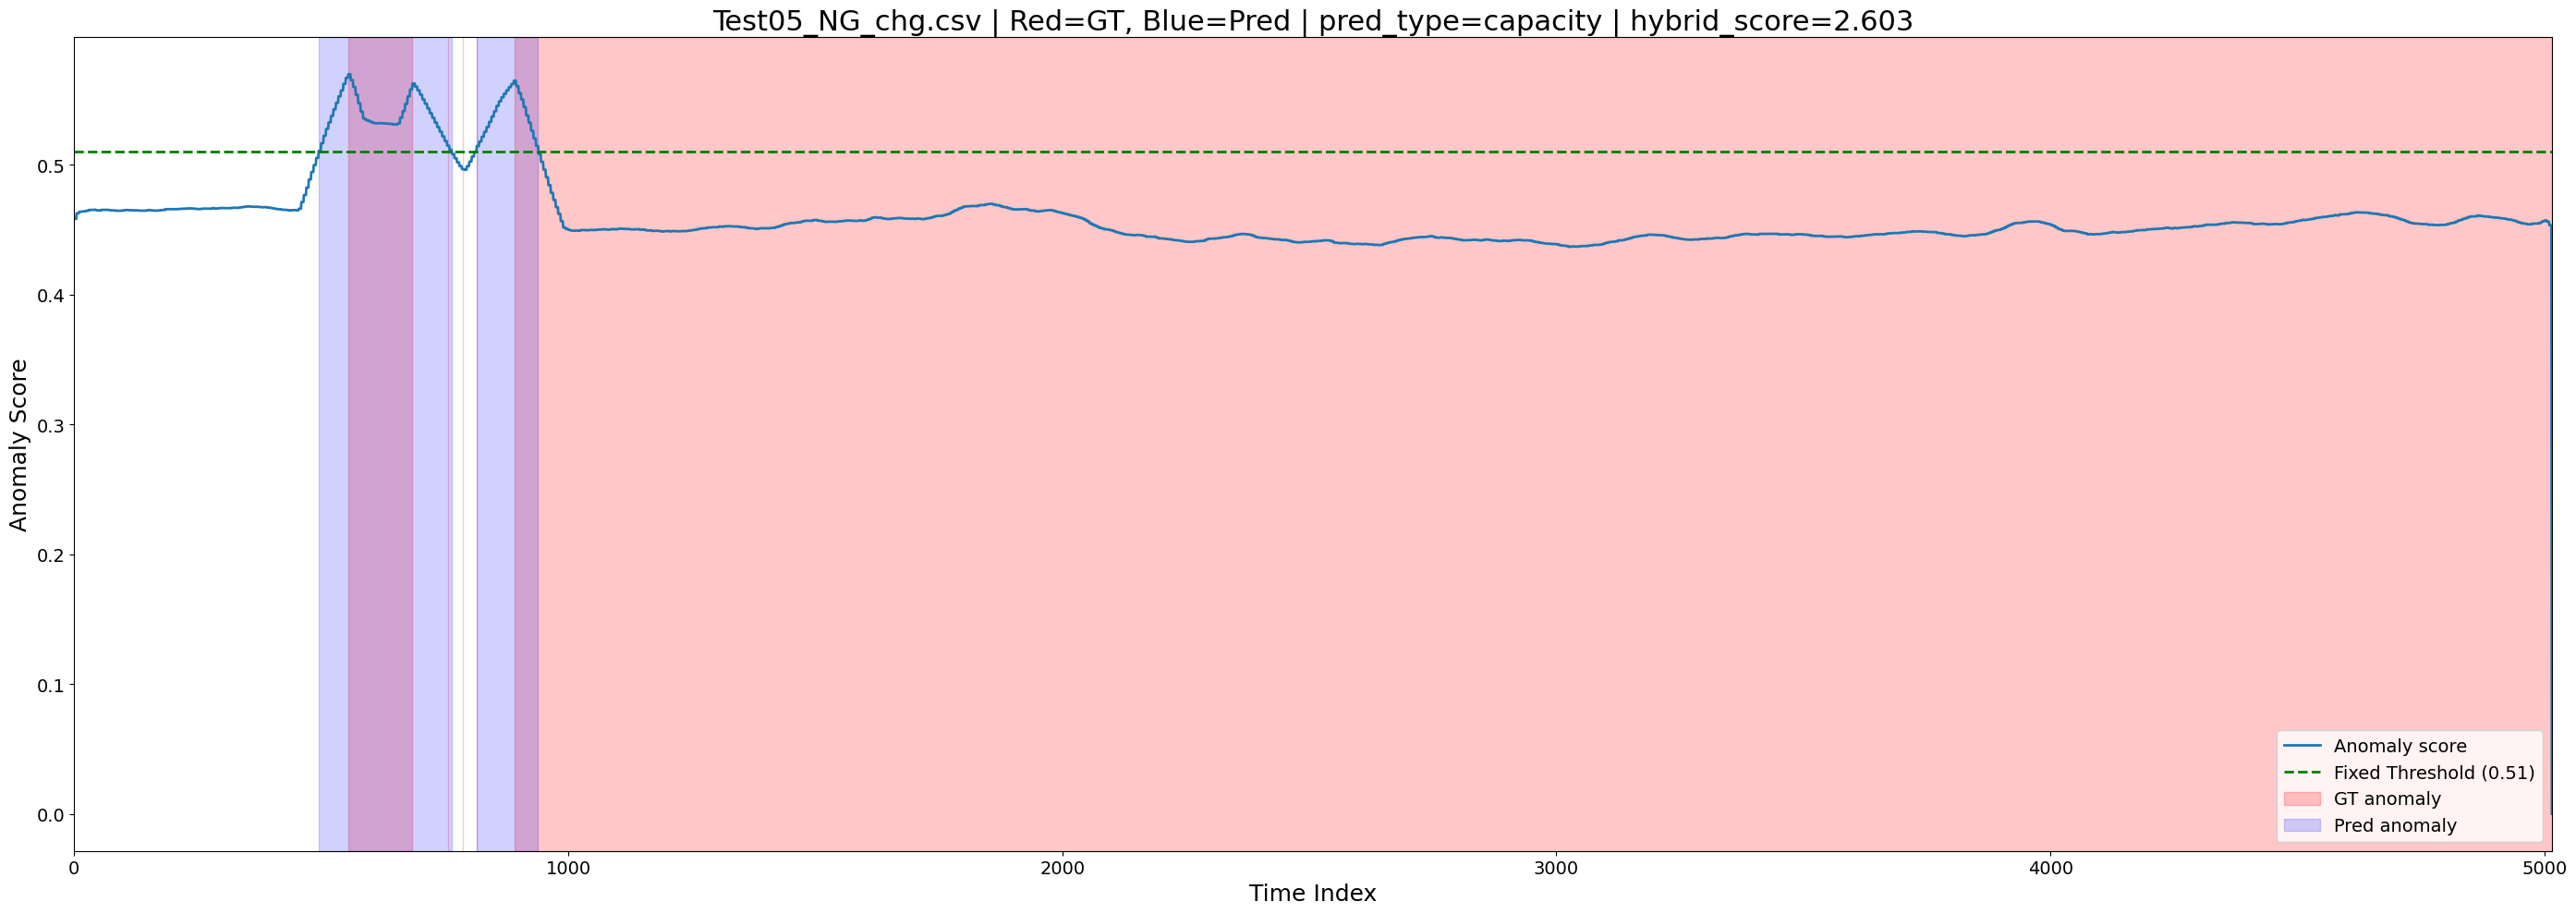

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def binary_to_ranges(binary_array):
    """0, 1로 이루어진 배열을 (start, end) 튜플 리스트로 변환"""
    ranges = []
    in_range = False
    start = 0
    for i, val in enumerate(binary_array):
        if val == 1 and not in_range:
            start = i
            in_range = True
        elif val == 0 and in_range:
            ranges.append((start, i - 1))
            in_range = False
    if in_range:
        ranges.append((start, len(binary_array) - 1))
    return ranges

def load_label_binary(label_path, n):
    """라벨 파일에서 실제 이상치(1) 정답을 가져옴"""
    lab = pd.read_csv(label_path)
    y_true = lab.iloc[:, -1].astype(int).to_numpy()
    return y_true[:n]

def plot_anomaly_guidebook_fixed(result: dict, label_path: str = None, absolute_threshold: float = 1.0, title: str = None):
    """
    guidebook.ipynb 방식의 시각화 함수 적용 
    (수정됨: 파일별 비율이 아닌, 고정된 절대 임계값을 사용하여 정상 파일에서 파란색이 뜨지 않게 함)
    """
    scores = np.asarray(result["timestep_scores"], dtype=float)
    df = result["df"]
    n = len(df)
    time = np.arange(n)

    # 핵심 수정: 전달받은 고정 임계값(absolute_threshold)을 사용
    # 점수가 이 고정값을 넘지 않으면 y_pred는 모두 0이 되어 파란색 구간이 생기지 않음
    thr = absolute_threshold
    y_pred = (scores >= thr).astype(int)
    pred_ranges = binary_to_ranges(y_pred)

    # 실제 이상치(GT) 구간 계산
    y_true = None
    gt_ranges = []
    if label_path is not None and os.path.exists(label_path):
        y_true = load_label_binary(label_path, n=n)
        gt_ranges = binary_to_ranges(y_true)

    # 그래프 사이즈 설정
    plt.figure(figsize=(28, 10))

    # 1. Anomaly score 선 그리기
    plt.plot(time, scores, linewidth=2, label="Anomaly score")
    plt.axhline(thr, linestyle="--", linewidth=2, color="green",
                label=f"Fixed Threshold ({thr})")

    # 2. GT(실제 이상) = 빨간색 배경
    for i, (s, e) in enumerate(gt_ranges):
        plt.axvspan(s, e, color="red", alpha=0.22,
                    label="GT anomaly" if i == 0 else None)

    # 3. Pred(예측 이상) = 파란색 배경
    for i, (s, e) in enumerate(pred_ranges):
        plt.axvspan(s, e, color="blue", alpha=0.18,
                    label="Pred anomaly" if i == 0 else None)

    # 타이틀 및 꾸미기
    plot_title = title or os.path.basename(result["file"])
    
    # dict 내부에 pred_type이나 hybrid_score가 없을 경우를 대비해 get() 사용
    p_type = result.get('pred_type', 'Unknown')
    h_score = result.get('hybrid_score', 0.0)
    
    plt.title(
        f"{plot_title} | Red=GT, Blue=Pred | "
        f"pred_type={p_type} | hybrid_score={h_score:.3f}",
        fontsize=22
    )
    plt.xlabel("Time Index", fontsize=18)
    plt.ylabel("Anomaly Score", fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim([time[0], time[-1]])
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행 코드 부분
# ==========================================

TARGET_FILE = "Test05_NG_chg.csv"

# Label 파일 경로 결합 (정상 파일이므로 Label이 없다면 None으로 처리)
# 만약 라벨 파일이 존재한다면 아래 주석을 풀고 경로를 지정하세요.
LABEL_FILE = "Test05_NG_chg_Label.csv"
label_path = os.path.join(TEST_LABEL_DIR, LABEL_FILE)


# 새로운 시각화 함수 호출
# 주의: absolute_threshold 값을 모델의 정상 점수 분포에 맞게 조절해야 합니다.
# 예: 정상 데이터의 Anomaly score가 보통 0.5를 넘지 않는다면 1.0 등으로 설정
plot_anomaly_guidebook_fixed(
    result=results[TARGET_FILE],
    label_path=label_path,
    absolute_threshold=0.51
)